In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv('rake.csv')

In [4]:
df

,RDATE,RAKEID,RAKETYPE,EXAMSTTN,SNAME,ZONE,ARVLTIME,PLCTTIME,RELSTIME,DPRTTIME,AR_TO_PL,PL_TO_RL,PL_TO_RELS_TIME,AR_TO_DEP_TIME
0,01-04-2024 00:00,ERM 191023230004,BCN,ADRA,ADRA JN.,SE,01-04-2024 00:15,01-04-2024 00:15,01-04-2024 00:15,01-04-2024 03:39,0:00,0:00,3:24,3:24
1,01-04-2024 00:00,ADTP051223174340,BOBSNM1,ADTP,ADITYAPUR,SE,01-04-2024 11:00,01-04-2024 11:00,01-04-2024 11:00,01-04-2024 11:00,0:00,0:00,0:00,0:00
2,01-04-2024 00:00,ADTP181223200428,BOBSNM1,ADTP,ADITYAPUR,SE,01-04-2024 00:20,01-04-2024 00:20,01-04-2024 00:20,01-04-2024 00:25,0:00,0:00,0:05,0:05
3,01-04-2024 00:00,ADTP181223200428,BOBSNM1,ADTP,ADITYAPUR,SE,01-04-2024 00:30,01-04-2024 00:30,01-04-2024 07:30,01-04-2024 22:05,0:00,7:00,14:35,21:35
4,01-04-2024 00:00,NPRY210123213305,BOXNHL,ADTP,ADITYAPUR,SE,01-04-2024 13:00,01-04-2024 13:00,01-04-2024 13:00,01-04-2024 13:15,0:00,0:00,0:15,0:15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166104,31-03-2025 00:00,BZA 230225083606,BOXN,WDD,WEST DN DEPT CABIN,ER,31-03-2025 02:08,31-03-2025 03:00,31-03-2025 14:10,31-03-2025 14:25,0:52,11:10,0:15,12:17
166105,31-03-2025 00:00,DSN 111024171703,BCN,WDD,WEST DN DEPT CABIN,ER,31-03-2025 13:35,31-03-2025 13:45,31-03-2025 15:45,31-03-2025 15:50,0:10,2:00,0:05,2:15
166106,31-03-2025 00:00,ED 020624170029,BCN,WDD,WEST DN DEPT CABIN,ER,31-03-2025 06:00,31-03-2025 06:00,31-03-2025 08:45,31-03-2025 10:00,0:00,2:45,1:15,4:00
166107,31-03-2025 00:00,JTJ 110924235623,BCN,WDD,WEST DN DEPT CABIN,ER,31-03-2025 11:45,31-03-2025 11:45,31-03-2025 12:50,31-03-2025 13:25,0:00,1:05,0:35,1:40


In [5]:
!git clone https://github.com/hk7131/hk7131.git

fatal: destination path 'hk7131' already exists and is not an empty directory.


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 166109 entries, 0 to 166108
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   RDATE            166109 non-null  object
 1   RAKEID           166109 non-null  object
 2   RAKETYPE         166109 non-null  object
 3   EXAMSTTN         166109 non-null  object
 4   SNAME            166109 non-null  object
 5   ZONE             166109 non-null  object
 6   ARVLTIME         166109 non-null  object
 7   PLCTTIME         166109 non-null  object
 8   RELSTIME         166109 non-null  object
 9   DPRTTIME         166109 non-null  object
 10  AR_TO_PL         166109 non-null  object
 11  PL_TO_RL         166109 non-null  object
 12  PL_TO_RELS_TIME  166109 non-null  object
 13  AR_TO_DEP_TIME   166109 non-null  object
dtypes: object(14)
memory usage: 17.7+ MB


In [7]:
df_encode=df.copy()

In [8]:
df_encode['RDATE']=pd.to_datetime(df['RDATE'],format='%d-%m-%Y %H:%M')

In [9]:
df_encode['RDATE']

0        2024-04-01
1        2024-04-01
2        2024-04-01
3        2024-04-01
4        2024-04-01
            ...    
166104   2025-03-31
166105   2025-03-31
166106   2025-03-31
166107   2025-03-31
166108   2025-03-31
Name: RDATE, Length: 166109, dtype: datetime64[ns]

In [10]:
df_encode['MONTH'] = df_encode['RDATE'].dt.to_period('M')

In [11]:
boxn=df_encode[df_encode['RAKETYPE'] == 'BOXN']

In [12]:
boxnhl=df_encode[df_encode['RAKETYPE'] == 'BOXNHL']

In [13]:
monthly_boxn = boxn.groupby('MONTH').size() 
print(monthly_boxn)

MONTH
2024-04    2737
2024-05    2683
2024-06    2468
2024-07    2619
2024-08    2432
2024-09    2429
2024-10    2747
2024-11    2045
2024-12    2556
2025-01    2451
2025-02    2222
2025-03    2589
Freq: M, dtype: int64


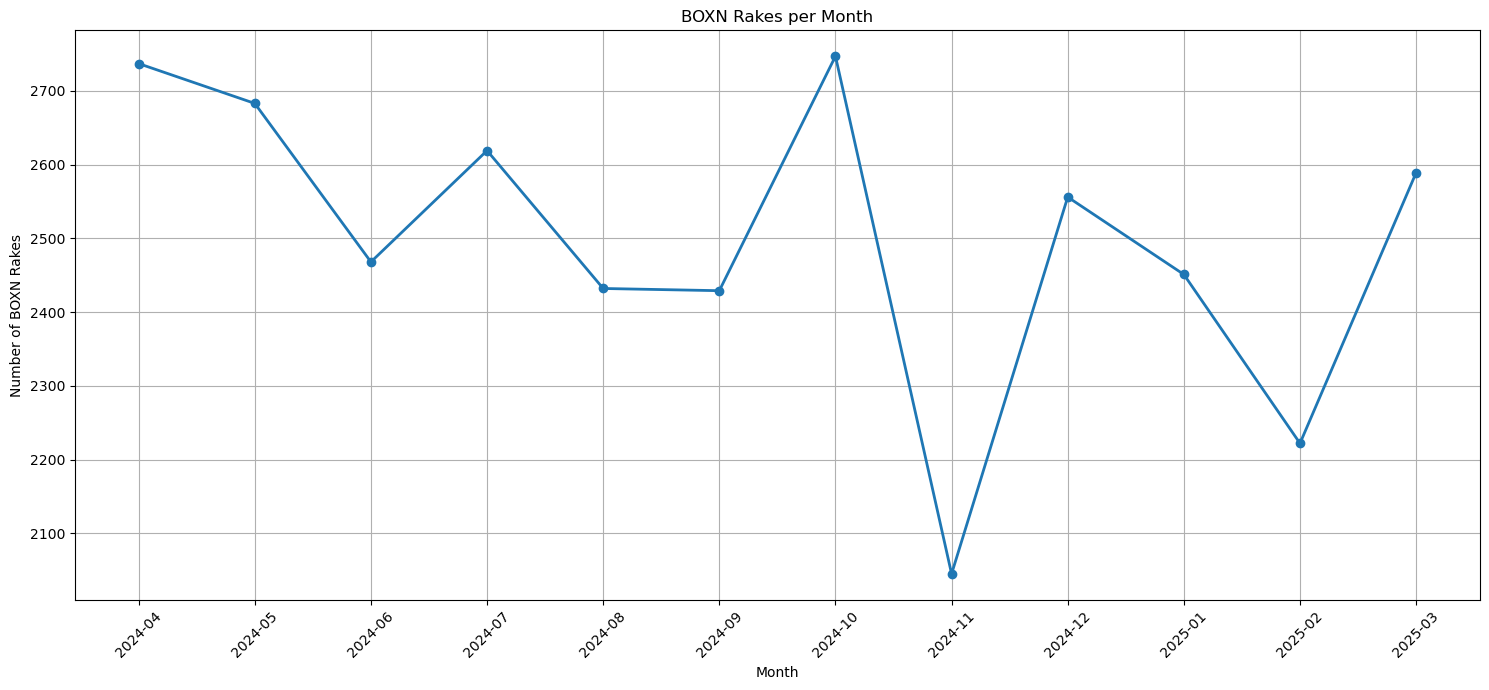

In [14]:
monthly_boxn = boxn.groupby('MONTH').size() 

plt.figure(figsize=(15, 7))

plt.plot(
    monthly_boxn.index.astype(str),
    monthly_boxn.values,
    marker='o',
    linewidth=2
)

plt.xlabel('Month')
plt.ylabel('Number of BOXN Rakes')
plt.title('BOXN Rakes per Month')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

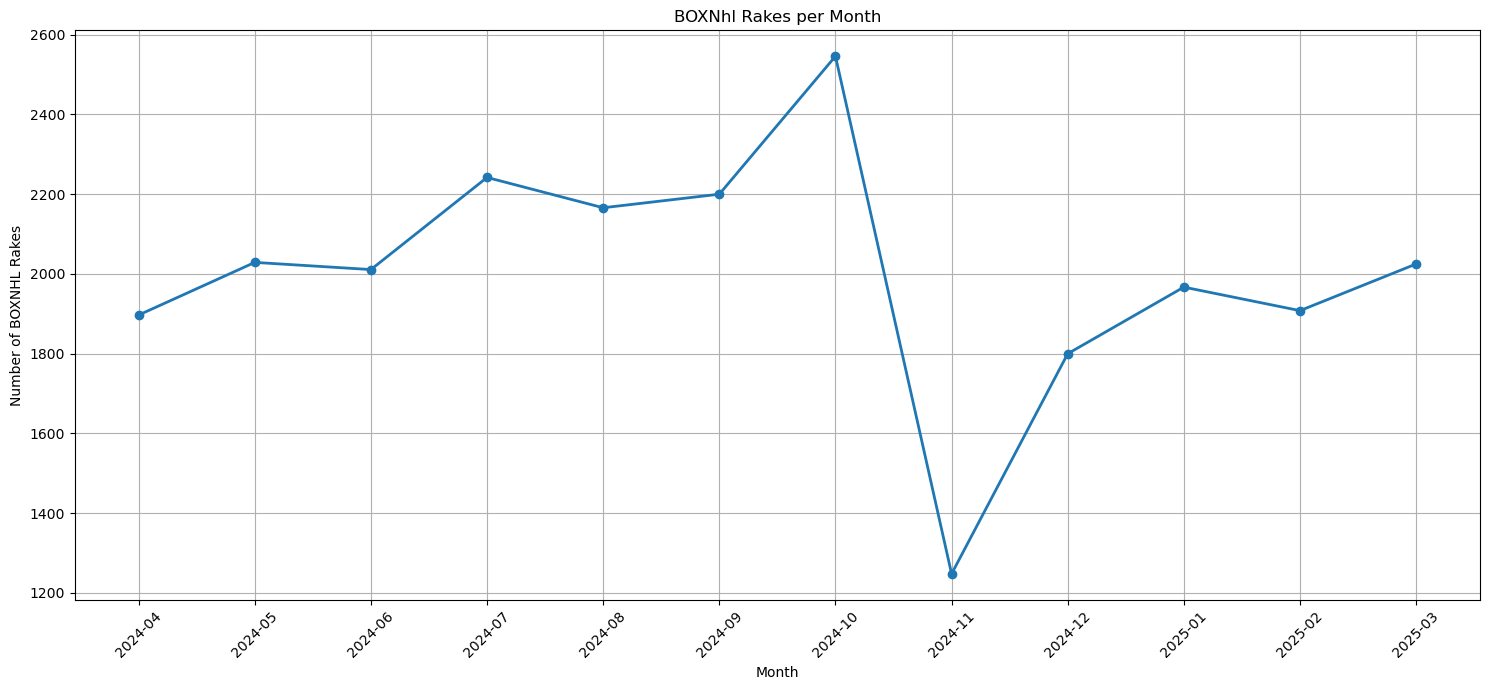

In [15]:
monthly_boxnhl = boxnhl.groupby('MONTH').size() 

plt.figure(figsize=(15, 7))

plt.plot(
    monthly_boxnhl.index.astype(str),
    monthly_boxnhl.values,
    marker='o',
    linewidth=2
)

plt.xlabel('Month')
plt.ylabel('Number of BOXNHL Rakes')
plt.title('BOXNhl Rakes per Month')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

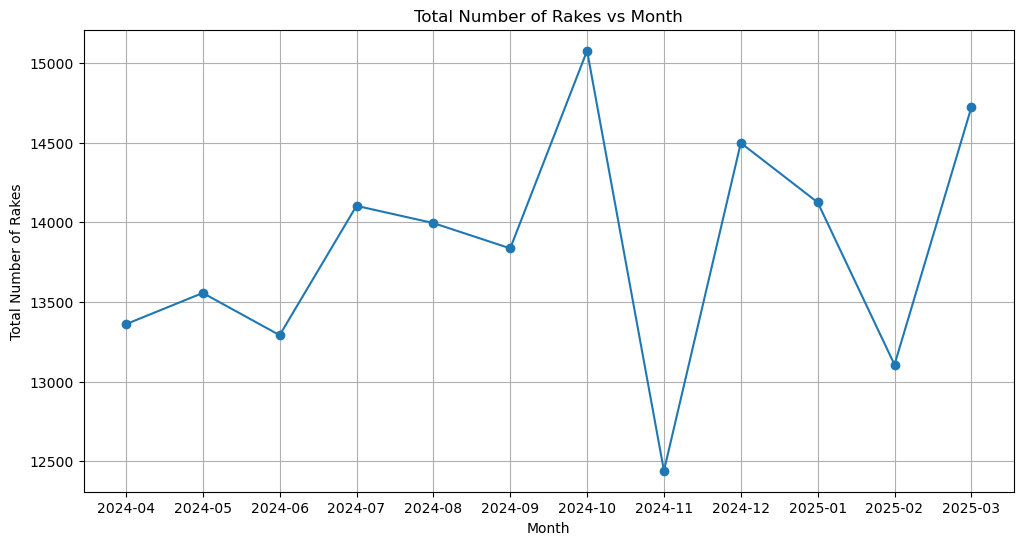

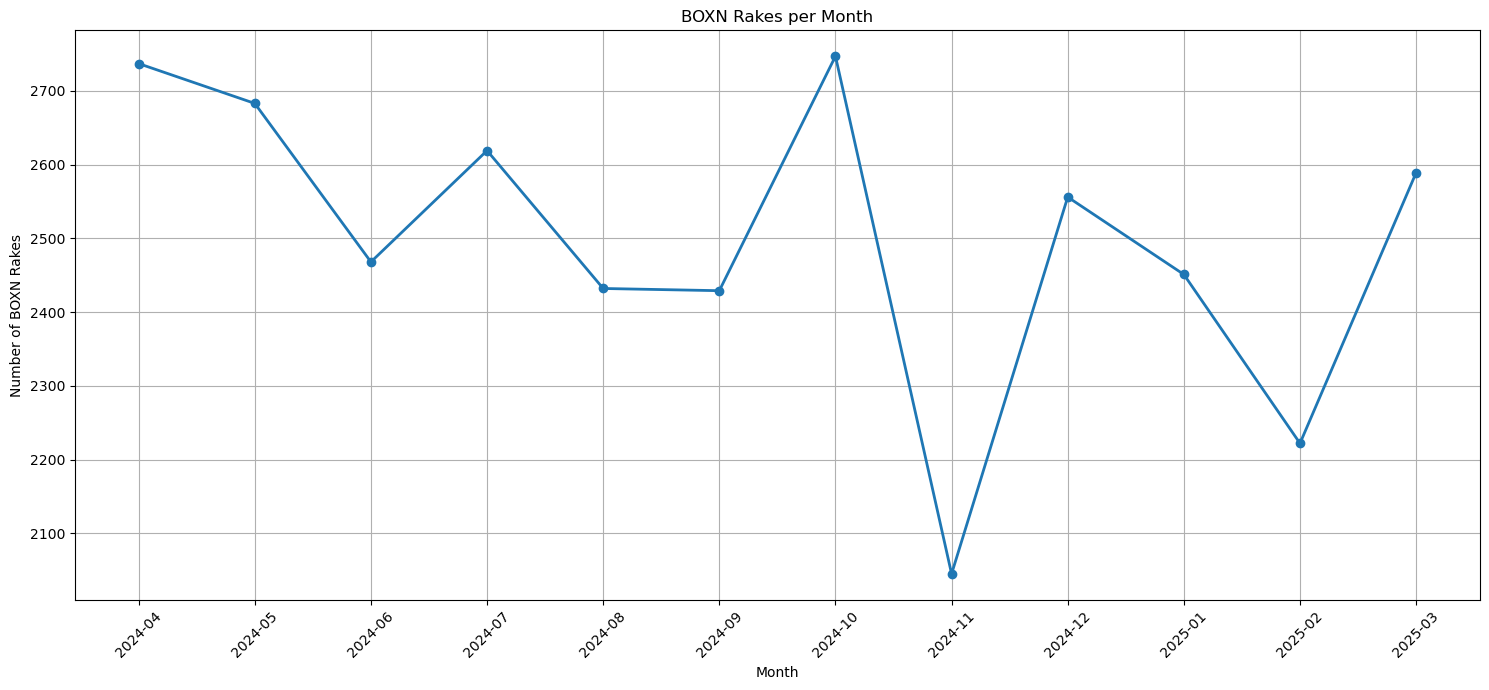

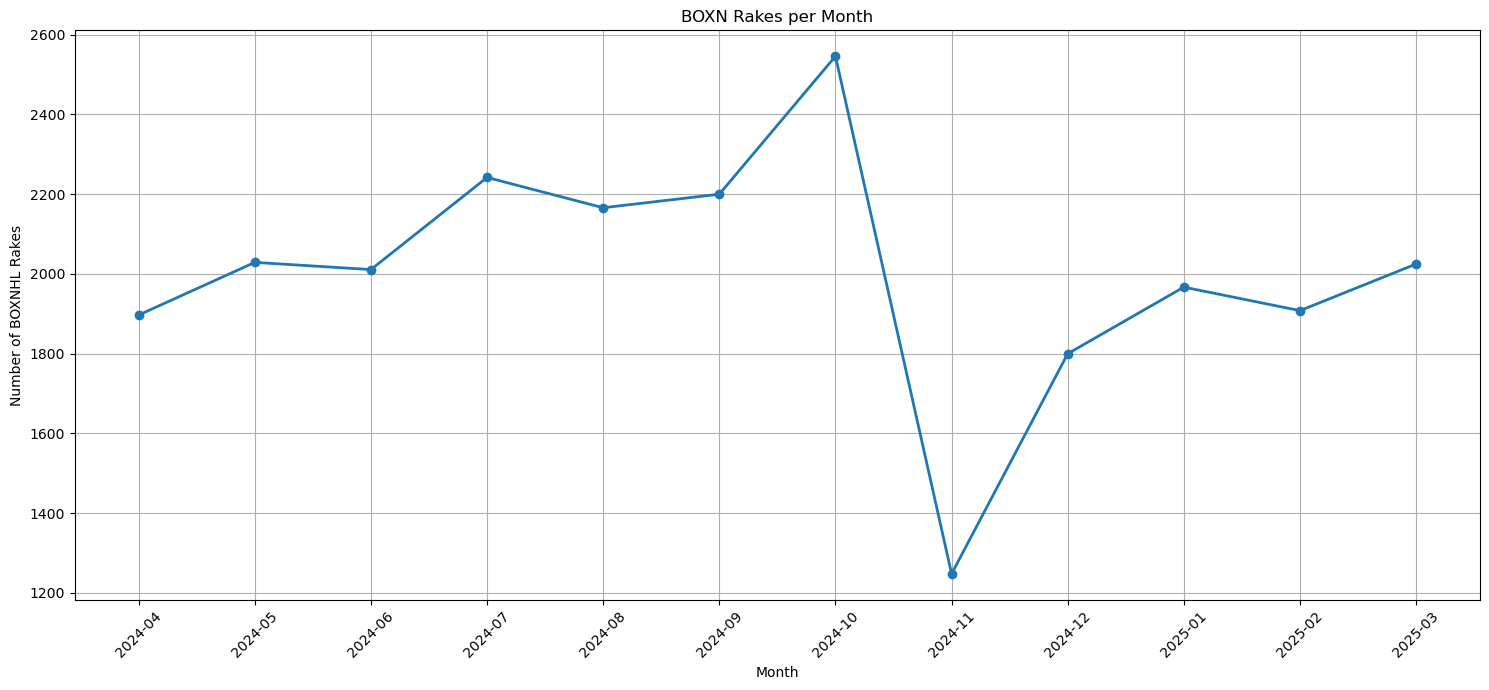

In [16]:
# Count total rakes for each month
monthly_rakes = df_encode.groupby('MONTH').size()

# Plot
plt.figure(figsize=(12, 6))
plt.plot(monthly_rakes.index.astype(str), monthly_rakes.values, marker='o')

plt.xlabel('Month')
plt.ylabel('Total Number of Rakes')
plt.title('Total Number of Rakes vs Month')
plt.grid(True)

plt.show()
monthly_boxn = boxn.groupby('MONTH').size() 

plt.figure(figsize=(15, 7))

plt.plot(
    monthly_boxn.index.astype(str),
    monthly_boxn.values,
    marker='o',
    linewidth=2
)

plt.xlabel('Month')
plt.ylabel('Number of BOXN Rakes')
plt.title('BOXN Rakes per Month')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()
monthly_boxnhl = boxnhl.groupby('MONTH').size() 

plt.figure(figsize=(15, 7))

plt.plot(
    monthly_boxnhl.index.astype(str),
    monthly_boxnhl.values,
    marker='o',
    linewidth=2
)

plt.xlabel('Month')
plt.ylabel('Number of BOXNHL Rakes')
plt.title('BOXN Rakes per Month')

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [17]:
df_encode['MONTH']

0         2024-04
1         2024-04
2         2024-04
3         2024-04
4         2024-04
           ...   
166104    2025-03
166105    2025-03
166106    2025-03
166107    2025-03
166108    2025-03
Name: MONTH, Length: 166109, dtype: period[M]

In [18]:
df['RAKETYPE'].value_counts()

RAKETYPE
BCN           45014
BOXN          29978
BOXNHL        24039
BLC           17350
BTPN           6806
BCNHL          6639
BOBRN          6586
SHRN           4133
BRN            3789
NMG            3428
BCNAHSM1       2257
BOBYN          2150
BOXNHL25T      1736
BOST           1412
BOXNS          1401
BLL            1130
BTPG           1052
BCACBM         1003
BOBSNM1         828
BLSS            667
BFNV            651
BTAP            639
MILY            629
BKI             574
BCFCM           285
BOYEL           280
BCCW            270
BTFLN           203
BOBR            177
DBKM            172
BRN22.9         139
BFNS22.9        121
BCBFG            86
BOSM             74
BOBRNHSM2        67
BTCS             66
NMGHS            54
BFNSM            36
BFNS             28
BCFC             27
BOXNEL           26
NMGH             21
BOBRNAHSM1       15
BCFCE            14
MBOXN            13
BOBYNHS           8
BWTB              6
BOBRNHSM1         5
BOM               5
BRHNEHS    

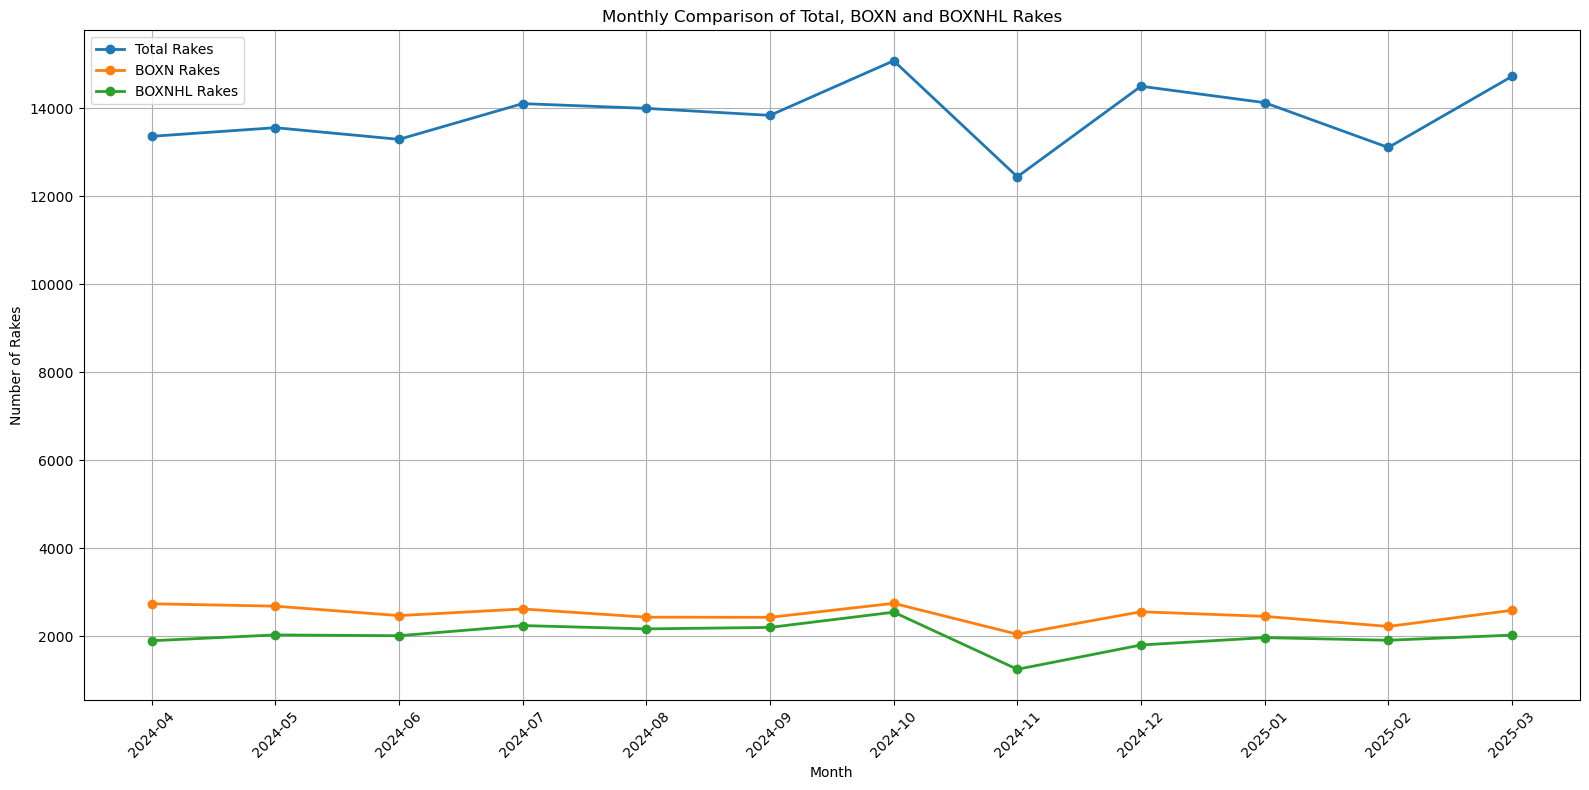

In [19]:
# Count rakes for each month
monthly_rakes = df_encode.groupby('MONTH').size()
monthly_boxn = boxn.groupby('MONTH').size()
monthly_boxnhl = boxnhl.groupby('MONTH').size()

# Plot all 3
plt.figure(figsize=(16, 8))

plt.plot(
    monthly_rakes.index.astype(str),
    monthly_rakes.values,
    marker='o',
    linewidth=2,
    label='Total Rakes'
)

plt.plot(
    monthly_boxn.index.astype(str),
    monthly_boxn.values,
    marker='o',
    linewidth=2,
    label='BOXN Rakes'
)

plt.plot(
    monthly_boxnhl.index.astype(str),
    monthly_boxnhl.values,
    marker='o',
    linewidth=2,
    label='BOXNHL Rakes'
)

plt.xlabel('Month')
plt.ylabel('Number of Rakes')
plt.title('Monthly Comparison of Total, BOXN and BOXNHL Rakes')

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [20]:
df_bcn = df_encode[df_encode['RAKETYPE'] == 'BCN']
monthly_bcn = df_bcn.groupby('MONTH').size()

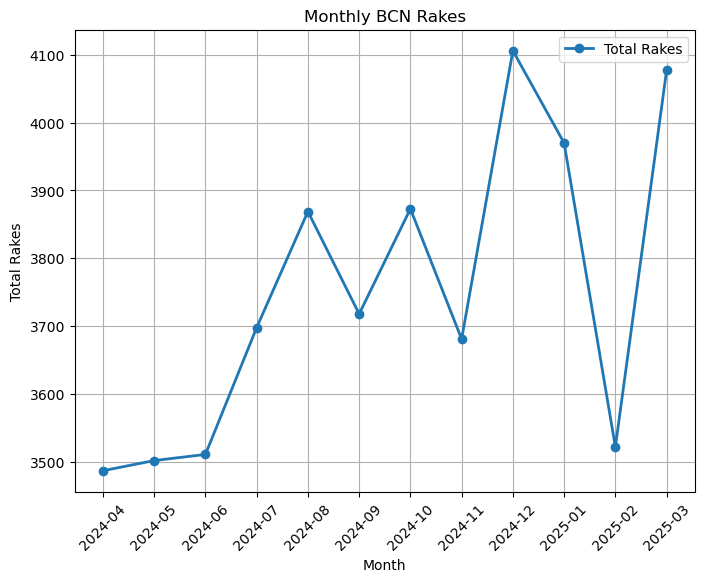

In [21]:
plt.figure(figsize=(8, 6))
plt.plot(
    monthly_bcn.index.astype(str),
    monthly_bcn.values,
    marker='o',
    linewidth=2,
    linestyle='-',
    label='Total Rakes'
)
plt.xlabel('Month')
plt.ylabel('Total Rakes')
plt.title('Monthly BCN Rakes')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()

plt.show()

Prediction of BCN RAKE

In [22]:
X = df_bcn.drop(columns=[
    'RDATE',
    'RAKEID',
    'PL_TO_RL',
    'PL_TO_RELS_TIME',
    'ARVLTIME',
    'PLCTTIME',
    'RELSTIME',
    'DPRTTIME',
    'RAKETYPE'
])

y = df_bcn['PL_TO_RL']

In [23]:
X.head()

,EXAMSTTN,SNAME,ZONE,AR_TO_PL,AR_TO_DEP_TIME,MONTH
0,ADRA,ADRA JN.,SE,0:00,3:24,2024-04
16,BKDC,OUTWARD YARD 'D' CABIN OF M/S BSL,SE,0:00,7:40,2024-04
32,BNDM,BONDA MUNDA JN.,SE,0:00,0:01,2024-04
34,BNDM,BONDA MUNDA JN.,SE,0:00,1:41,2024-04
39,BPA,BELAMPALLI,SC,0:00,2:08,2024-04


In [24]:
time_cols = ['AR_TO_PL', 'AR_TO_DEP_TIME']

print(X[time_cols].head(10))
print(X[time_cols].dtypes)

   AR_TO_PL AR_TO_DEP_TIME
0      0:00           3:24
16     0:00           7:40
32     0:00           0:01
34     0:00           1:41
39     0:00           2:08
41     0:00           4:49
48     1:10          16:20
49     0:00           4:07
52     0:00           2:00
53     0:00           0:00
AR_TO_PL          object
AR_TO_DEP_TIME    object
dtype: object


In [25]:
time_cols = ['AR_TO_PL','AR_TO_DEP_TIME']

for col in time_cols:
    X[col] = pd.to_timedelta(
        '00:' + X[col].astype(str)
    ).dt.total_seconds()

In [26]:
X=pd.get_dummies(X,columns=['EXAMSTTN','SNAME','ZONE','MONTH'],drop_first=True)


In [27]:
y = pd.to_timedelta(y + ':00').dt.total_seconds() 

In [28]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

In [29]:
from sklearn.linear_model import LinearRegression
model_linear=LinearRegression()
model_linear.fit(X_train,y_train)

LinearRegression()

In [30]:
y_pred=model_linear.predict(X_test)

In [31]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print(r2)

0.45116822147286506


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE:", mae, "seconds")
print("RMSE:", rmse, "seconds")
print("R²:", r2)

MAE: 9467.910568937827 seconds
RMSE: 17392.91006461887 seconds
R²: 0.45116822147286506


In [33]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

 
model_rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", mae, "seconds")
print("MAE :", mae / 60, "minutes")
print("RMSE:", rmse, "seconds")
print("RMSE:", rmse / 60, "minutes")
print("R²  :", r2)

Random Forest Results
MAE : 3480.6557758443178 seconds
MAE : 58.010929597405294 minutes
RMSE: 9842.35737040486 seconds
RMSE: 164.03928950674765 minutes
R²  : 0.8242509414324127


In [34]:
param_grid={
    'n_estimators':[50,100],'max_depth':[None,5,10],
     
}

In [35]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Gradient Boosting model
model_gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)


model_gb.fit(X_train, y_train)

# Predict
y_pred_gb = model_gb.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred_gb)
rmse = mean_squared_error(y_test, y_pred_gb) ** 0.5
r2 = r2_score(y_test, y_pred_gb)

print("Gradient Boosting Results")
print("MAE :", mae, "seconds")
print("MAE :", mae / 60, "minutes")
print("RMSE:", rmse, "seconds")
print("RMSE:", rmse / 60, "minutes")
print("R²  :", r2)


Gradient Boosting Results
MAE : 5802.909692747783 seconds
MAE : 96.71516154579639 minutes
RMSE: 12275.02576875232 seconds
RMSE: 204.58376281253868 minutes
R²  : 0.7266371004347738


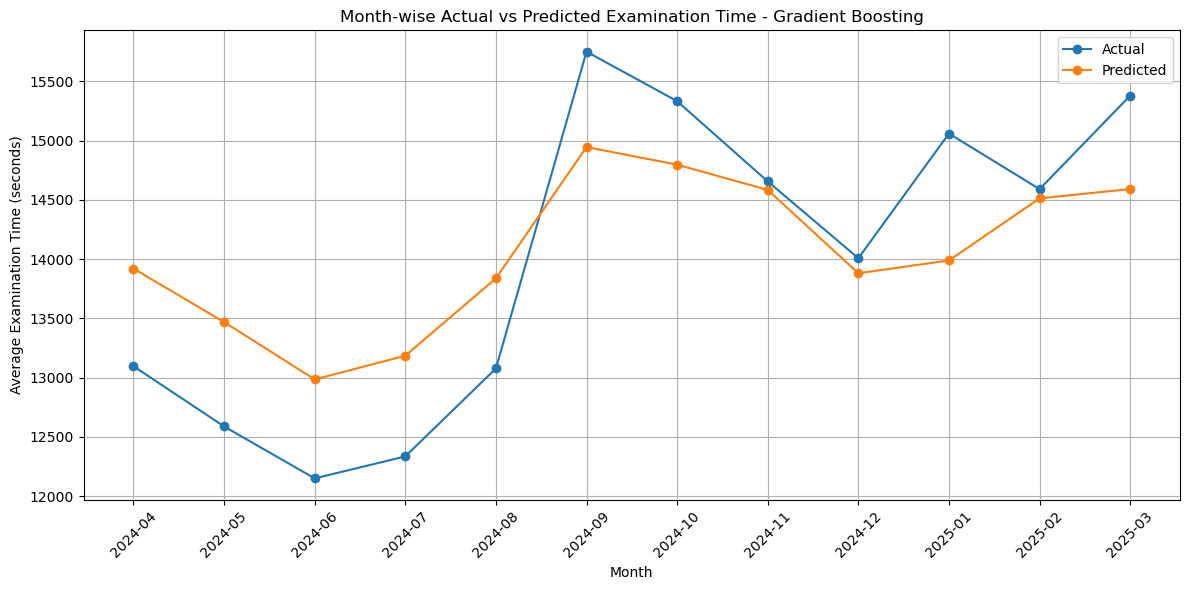

In [36]:
# Gradient Boosting predictions
y_pred_gb = model_gb.predict(X_test)

# Create result
result = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_gb,
    'MONTH': df_bcn.loc[y_test.index, 'MONTH'].astype(str).values
})

# Monthly average
monthly = result.groupby('MONTH')[['Actual', 'Predicted']].mean()

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    monthly.index,
    monthly['Actual'],
    marker='o',
    label='Actual'
)

plt.plot(
    monthly.index,
    monthly['Predicted'],
    marker='o',
    label='Predicted'
)

plt.xlabel('Month')
plt.ylabel('Average Examination Time (seconds)')
plt.title('Month-wise Actual vs Predicted Examination Time - Gradient Boosting')
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

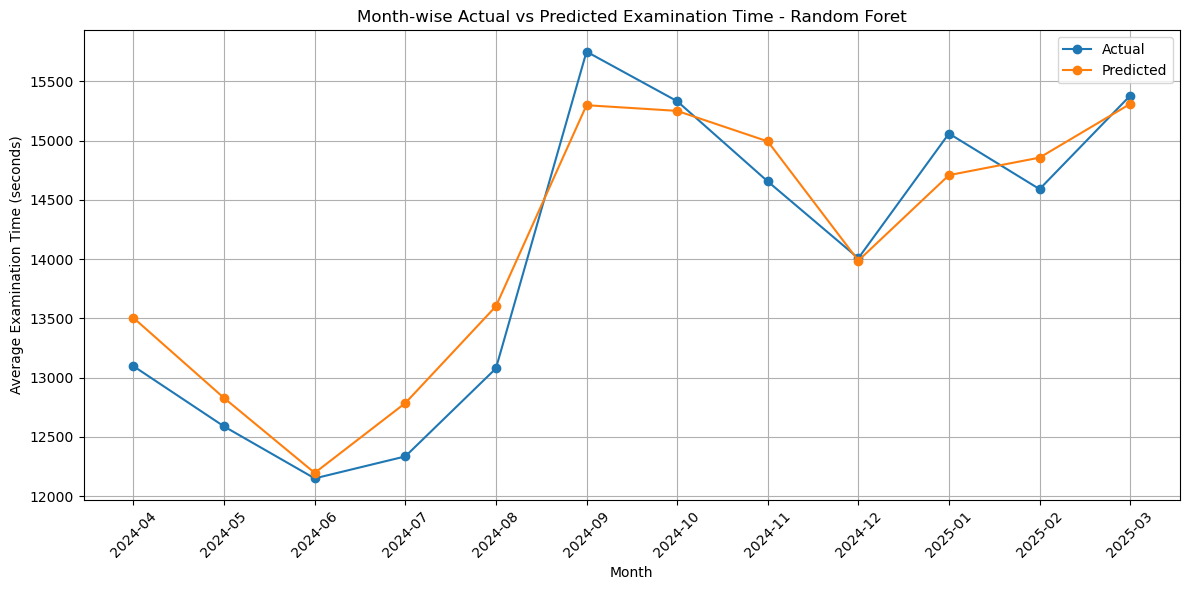

In [37]:
#RANDOM FOREST predictions
y_pred_rf = model_rf.predict(X_test)

# Create result
result = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_rf,
    'MONTH': df_bcn.loc[y_test.index, 'MONTH'].astype(str).values
})

# Monthly average
monthly = result.groupby('MONTH')[['Actual', 'Predicted']].mean()

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    monthly.index,
    monthly['Actual'],
    marker='o',
    label='Actual'
)

plt.plot(
    monthly.index,
    monthly['Predicted'],
    marker='o',
    label='Predicted'
)

plt.xlabel('Month')
plt.ylabel('Average Examination Time (seconds)')
plt.title('Month-wise Actual vs Predicted Examination Time - Random Foret')
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

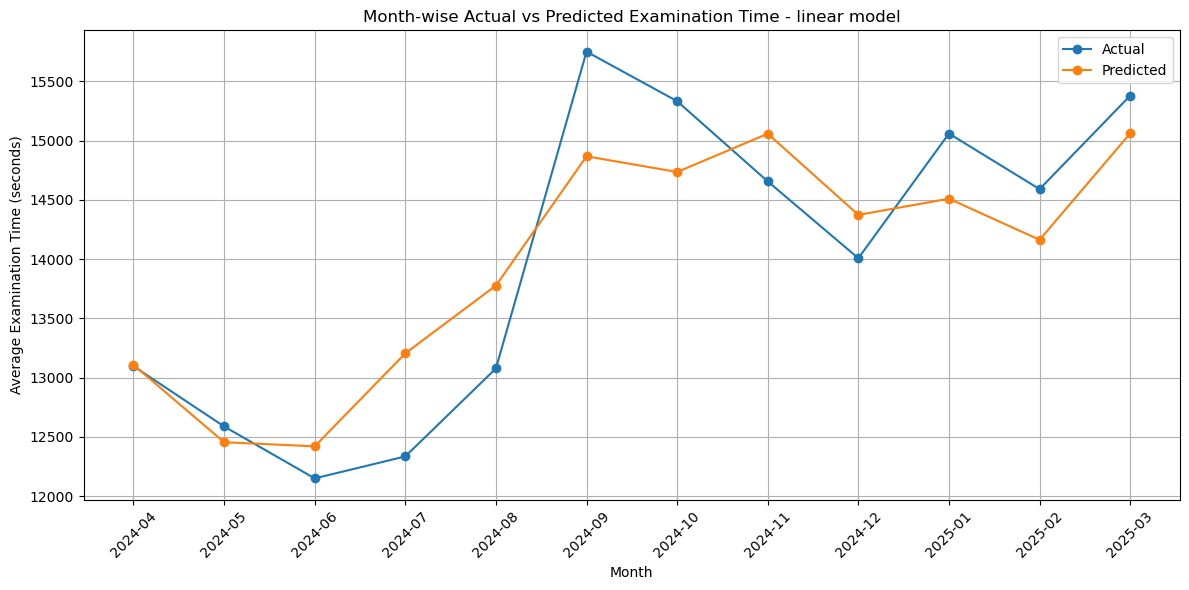

In [38]:
#linear model predictions
y_pred_ll = model_linear.predict(X_test)

# Create result
result = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_ll,
    'MONTH': df_bcn.loc[y_test.index, 'MONTH'].astype(str).values
})

# Monthly average
monthly = result.groupby('MONTH')[['Actual', 'Predicted']].mean()

# Plot
plt.figure(figsize=(12, 6))

plt.plot(
    monthly.index,
    monthly['Actual'],
    marker='o',
    label='Actual'
)

plt.plot(
    monthly.index,
    monthly['Predicted'],
    marker='o',
    label='Predicted'
)

plt.xlabel('Month')
plt.ylabel('Average Examination Time (seconds)')
plt.title('Month-wise Actual vs Predicted Examination Time - linear model')
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [50, 100, 150,200],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

randomised_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    n_jobs=-1,
    random_state=42,
 )

randomised_search.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=RandomForestRegressor(n_jobs=-1, random_state=42),
                   n_iter=5, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, 20],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [50, 100, 150, 200]},
                   random_state=42)

In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

 
model_rf = RandomForestRegressor(
   max_depth=20, max_features='log2', min_samples_leaf=2,
                      min_samples_split=10, n_estimators=50, n_jobs=-1,
                      random_state=42
)

model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", mae, "seconds")
print("MAE :", mae / 60, "minutes")
print("RMSE:", rmse, "seconds")
print("RMSE:", rmse / 60, "minutes")
print("R²  :", r2)

Random Forest Results
MAE : 6902.759160551758 seconds
MAE : 115.04598600919597 minutes
RMSE: 14719.084933061185 seconds
RMSE: 245.31808221768642 minutes
R²  : 0.6069422443788524
